In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv(
    "/content/drive/MyDrive/Customer_project/final_02_comp.csv"
)

df.head()

,Complaint,Product,Complaint_Length,Processed_Complaint
0,Received Capital One charge card offer XXXX. A...,Credit card,714,received capital one charge card offer applied...
1,I do n't know how they got my cell number. I t...,Debt collection,52,nt know got cell number told would deal onlybw...
2,I 'm a longtime member of Charter One Bank/RBS...,Credit card,692,longtime member charter one bankrbs citizen ba...
3,"After looking at my credit report, I saw a col...",Credit reporting,84,looking credit report saw collection account b...
4,I received a call from a XXXX XXXX from XXXX @...,Debt collection,140,received call ext stating owed wanted however ...


In [ ]:
X = df["Processed_Complaint"]
y = df["Product"]

In [ ]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df["Product"])

joblib.dump(
    label_encoder,
    "/content/drive/MyDrive/Customer_project/models/label_encoder.pkl"
)

['/content/drive/MyDrive/Customer_project/models/label_encoder.pkl']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print(df.columns.tolist())

['Complaint', 'Product', 'Complaint_Length', 'Processed_Complaint']


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,
    min_df=5,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(90002, 14793)
(22501, 14793)


In [ ]:
joblib.dump(
    tfidf,
    "/content/drive/MyDrive/Customer_project/models/tfidf_vectorizer.pkl"
)

['/content/drive/MyDrive/Customer_project/models/tfidf_vectorizer.pkl']

In [ ]:
results = []

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

results = []

def evaluate_model(model, model_name):

    # Training Time
    start = time.time()
    model.fit(X_train_tfidf, y_train)
    training_time = time.time() - start

    # Prediction Time
    start = time.time()
    y_pred = model.predict(X_test_tfidf)
    prediction_time = time.time() - start

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    # Store Results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Training Time (sec)": round(training_time, 2),
        "Prediction Time (sec)": round(prediction_time, 2)
    })

    print("="*60)
    print(model_name)
    print("="*60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report\n")
    print(
        classification_report(
            y_test,
            y_pred

        )
    )

    # Confusion Matrix
    plt.figure(figsize=(10,8))

    sns.heatmap(
        confusion_matrix(y_test, y_pred),
        annot=False,
        cmap="Blues"
    )

    plt.title(model_name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return model

Logistic Regression (TF-IDF)
Accuracy : 0.8584
Precision: 0.8567
Recall   : 0.8584
F1 Score : 0.8560

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.83      0.83      2079
           1       0.80      0.65      0.72      1276
           2       0.82      0.84      0.83      2709
           3       0.87      0.87      0.87      4199
           4       0.83      0.88      0.85      5633
           5       0.78      0.58      0.66       215
           6       0.93      0.96      0.95      4925
           7       0.67      0.35      0.46       249
           8       0.81      0.67      0.74       228
           9       0.89      0.83      0.85       988

    accuracy                           0.86     22501
   macro avg       0.82      0.74      0.78     22501
weighted avg       0.86      0.86      0.86     22501



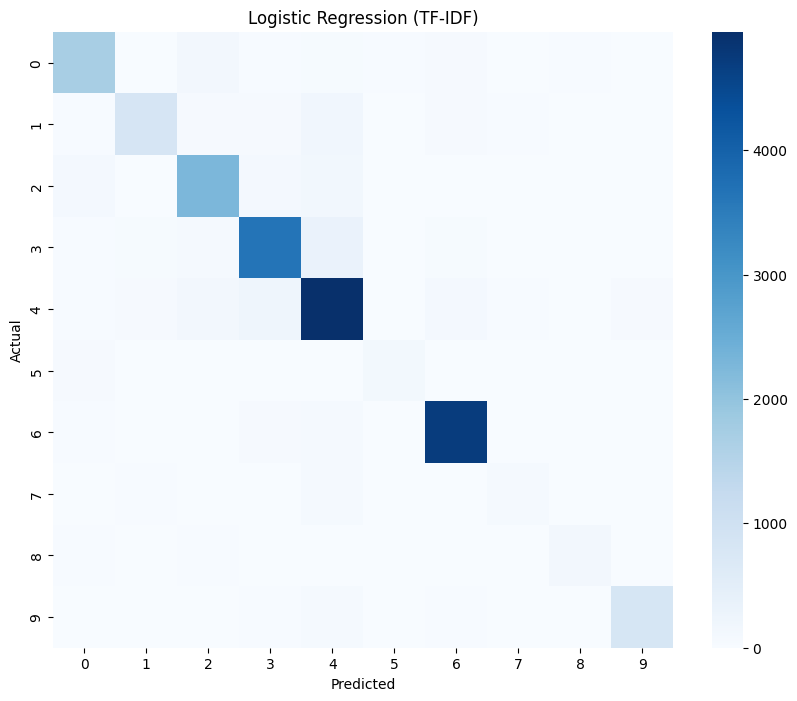

Logistic Regression Saved!


In [ ]:
lr_model = evaluate_model(
    LogisticRegression(
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ),
    "Logistic Regression (TF-IDF)"
)

joblib.dump(
    lr_model,
    "/content/drive/MyDrive/Customer_project/models/logistic_regression_tfidf.pkl"
)

print("Logistic Regression Saved!")

Random Forest (TF-IDF)
Accuracy : 0.8263
Precision: 0.8298
Recall   : 0.8263
F1 Score : 0.8136

Classification Report

              precision    recall  f1-score   support

           0       0.80      0.80      0.80      2079
           1       0.88      0.40      0.55      1276
           2       0.80      0.78      0.79      2709
           3       0.82      0.89      0.85      4199
           4       0.79      0.90      0.84      5633
           5       0.91      0.19      0.32       215
           6       0.87      0.96      0.91      4925
           7       0.83      0.08      0.14       249
           8       0.85      0.25      0.39       228
           9       0.92      0.70      0.80       988

    accuracy                           0.83     22501
   macro avg       0.85      0.59      0.64     22501
weighted avg       0.83      0.83      0.81     22501



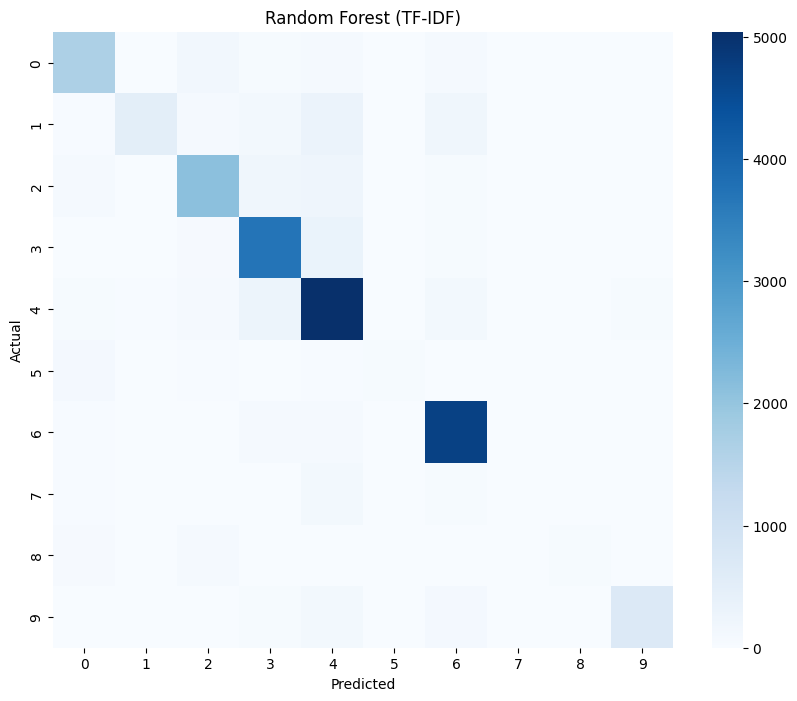

Random Forest Model Saved Successfully!


In [ ]:
rf_model = evaluate_model(
    RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Random Forest (TF-IDF)"
)

# Save Model
joblib.dump(
    rf_model,
    "/content/drive/MyDrive/Customer_project/models/random_forest_tfidf.pkl"
)

print("Random Forest Model Saved Successfully!")


XGBoost (TF-IDF)
Accuracy : 0.8390
Precision: 0.8375
Recall   : 0.8390
F1 Score : 0.8372

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.81      0.81      2079
           1       0.77      0.62      0.69      1276
           2       0.80      0.81      0.81      2709
           3       0.84      0.84      0.84      4199
           4       0.80      0.86      0.83      5633
           5       0.73      0.59      0.65       215
           6       0.93      0.94      0.94      4925
           7       0.58      0.39      0.47       249
           8       0.80      0.67      0.73       228
           9       0.87      0.86      0.86       988

    accuracy                           0.84     22501
   macro avg       0.80      0.74      0.76     22501
weighted avg       0.84      0.84      0.84     22501



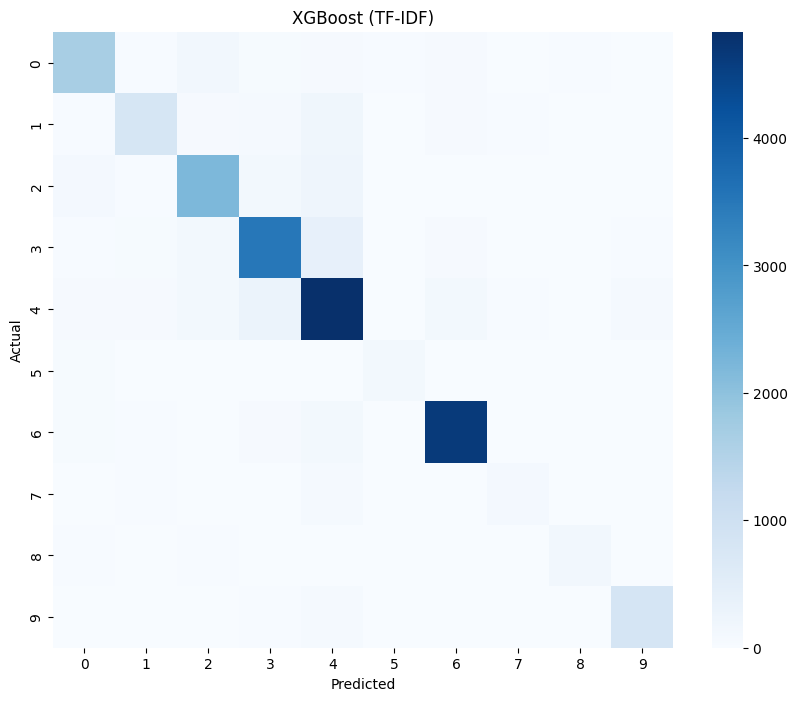

XGBoost Model Saved Successfully!


In [ ]:
xgb_model = evaluate_model(
    XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric="mlogloss",
        n_jobs=-1
    ),
    "XGBoost (TF-IDF)"
)

# Save Model
joblib.dump(
    xgb_model,
    "/content/drive/MyDrive/Customer_project/models/xgboost_tfidf.pkl"
)

print("XGBoost Model Saved Successfully!")

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (sec),Prediction Time (sec)
0,Logistic Regression (TF-IDF),0.858406,0.856709,0.858406,0.856044,30.92,0.04
2,XGBoost (TF-IDF),0.838985,0.837486,0.838985,0.837196,1259.60,1.26
1,Random Forest (TF-IDF),0.826274,0.829828,0.826274,0.813593,1037.53,2.74


/tmp/ipykernel_3050/2251505417.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


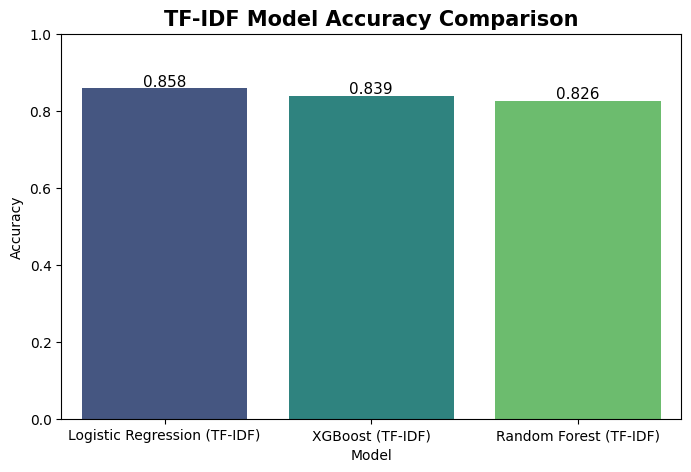

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.title(
    "TF-IDF Model Accuracy Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0,1)

for i, acc in enumerate(results_df["Accuracy"]):
    plt.text(i, acc+0.005, f"{acc:.3f}", ha='center', fontsize=11)

plt.show()